# Exercise: Neural Networks

## 1. Import the required libraries in the cell below

In [1]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

## 2. Read the data

In [2]:
housing = housing = pd.read_csv('./data/sacramento_real_estate_transactions.csv')
housing.head()


,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,Wed May 21 00:00:00 EDT 2008,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,Wed May 21 00:00:00 EDT 2008,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,Wed May 21 00:00:00 EDT 2008,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,Wed May 21 00:00:00 EDT 2008,81900,38.519470,-121.435768


## 3. Conduct Exploratory Data Analysis 

In [3]:
# Check data info
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 985 entries, 0 to 984
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   street     985 non-null    str    
 1   city       985 non-null    str    
 2   zip        985 non-null    int64  
 3   state      985 non-null    str    
 4   beds       985 non-null    int64  
 5   baths      985 non-null    int64  
 6   sq__ft     985 non-null    int64  
 7   type       985 non-null    str    
 8   sale_date  985 non-null    str    
 9   price      985 non-null    int64  
 10  latitude   985 non-null    float64
 11  longitude  985 non-null    float64
dtypes: float64(2), int64(5), str(5)
memory usage: 156.9 KB


In [4]:
# Check for missing values
housing.isnull().sum()


street       0
city         0
zip          0
state        0
beds         0
baths        0
sq__ft       0
type         0
sale_date    0
price        0
latitude     0
longitude    0
dtype: int64

In [5]:
# Check data types
housing.dtypes


street           str
city             str
zip            int64
state            str
beds           int64
baths          int64
sq__ft         int64
type             str
sale_date        str
price          int64
latitude     float64
longitude    float64
dtype: object

In [6]:
# Look at the Summary Stats.
housing.describe()


,zip,beds,baths,sq__ft,price,latitude,longitude
count,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000
mean,95750.697462,2.911675,1.776650,1312.918782,233715.951269,38.445121,-121.193371
std,85.176072,1.307932,0.895371,856.123224,139088.818896,5.103637,5.100670
min,95603.000000,0.000000,0.000000,-984.000000,-210944.000000,-121.503471,-121.551704
25%,95660.000000,2.000000,1.000000,950.000000,145000.000000,38.482704,-121.446119
50%,95762.000000,3.000000,2.000000,1304.000000,213750.000000,38.625932,-121.375799
75%,95828.000000,4.000000,2.000000,1718.000000,300000.000000,38.695589,-121.294893
max,95864.000000,8.000000,5.000000,5822.000000,884790.000000,39.020808,38.668433


In [7]:
# Cleaning Steps (if needed)
(housing[['beds', 'baths', 'sq__ft', 'price']] <= 0).sum()

beds      108
baths     108
sq__ft    172
price       1
dtype: int64

In [8]:
housing = housing.drop_duplicates()
housing.shape

(982, 12)

In [9]:
housing = housing[housing['sq__ft'] > 0]
housing.shape

(811, 12)

## 4. Split the Data & Pre-Processing
**Best Practice for Neural Network** Split your data before modeling into three part:

1. __The Training Set (The Textbook):__ This is the data the neural network actually looks at to learn. During the training loop, the network uses this data to adjust its **weights** and **biases** via backpropagation.

2. __The Validation Set (The Practice Quiz):__ This data evaluates the model *during* training to fine-tune settings. The model does not learn its weights from this data. Instead, the it uses the validation score to choose **hyperparameters** (like learning rate, number of layers, or node count) and to decide when to stop training (**early stopping**).


3. __The Test Set (The Final Exam):__ This data provides an unbiased, final evaluation of the model's real-world performance. This dataset is locked away until training is completely finished. It is only used *once* at the very end to see how well the network performs on truly unseen data.

__Typical Split Ratios__

Depending on the size of your total dataset, data scientists generally use these proportions:

| Dataset Size | Train | Validation | Test |
| :--- | :--- | :--- | :--- |
| **Traditional (Small/Medium Data)** | 60% | 20% | 20% |
| **Modern Deep Learning (Millions of Rows)** | 98% | 1% | 1% |

In [10]:
# Select the Features and Target
X = housing[['sq__ft']]     
y = housing['price'] 

In [11]:
# Split to Train Test & Validation
X_train_all, X_test, y_train_all, y_test = train_test_split(X, y, test_size=0.20,random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_all, y_train_all,test_size=0.20, random_state=42)

In [13]:
# IMPORTANT: Scale the features for Neural Networks
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

## 5. Linear Regression

In [14]:
# Initialize LinearRegression model
lr = LinearRegression()
lr

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
# Fit and check the Training Score
lr.fit(X_train_sc, y_train)
lr.score(X_train_sc, y_train)

0.44846417256742943

In [16]:
# Predict and check the Testing Score
y_pred = lr.predict(X_test_sc)
lr.score(X_test_sc, y_test)

0.5476197770333637

In [17]:
# Evaluate the model
# Coefficient 
print('Coefficient:', lr.coef_)

# Intercept
print('Intercept:', lr.intercept_)

# RMSE
print('RMSE:', root_mean_squared_error(y_test, y_pred))

Coefficient: [82568.6949645]
Intercept: 234511.44208494207
RMSE: 74987.14988237318


## 6. Build a Single Neural Network
Creating a model in `keras` entails a few steps:
1. Create your network topology
2. Compile your model
3. Fit your model
   
**Important Note on Regression:**
Because we are predicting a continuous value (house price), our network is performing regression, not classification. 
* Your **hidden layers** should generally use the `relu` activation function.
* Your **output layer** must have exactly **1 neuron** and **no activation function** (or `activation='linear'`) so it can predict any continuous number.
* When compiling, use `loss='mse'` (Mean Squared Error) and `metrics=['mae']` (Mean Absolute Error) so we can see the error in actual dollar amounts.

In [18]:
# Step 1: Define
model = Sequential()
model.add(Input(shape=(1,)))             
model.add(Dense(1, activation='linear')) 

# Step 2: Compile
model.compile(loss='mse', metrics=['mae'])

# Step 3: Fit
model.fit(X_train_sc, y_train,validation_data=(X_val_sc, y_val))

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 70197559296.0000 - mae: 234511.4062 - val_loss: 62151467008.0000 - val_mae: 221362.4531


In [19]:
# Model Weights
model.weights

[<Variable path=sequential/dense/kernel, shape=(1, 1), dtype=float32, value=[[0.8384105]]>,
 <Variable path=sequential/dense/bias, shape=(1,), dtype=float32, value=[0.02532234]>]

In [20]:
# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1)                   │               2 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6 (28.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4 (20.00 B)

## 7. Stacking Multiple Neurons

#### Shallow NN

In [21]:
# Step 1: Define
model = Sequential()
model.add(Input(shape=(1,)))   
model.add(Dense(3))   
model.add(Dense(1))

# Step 2: Compile
model.compile(loss='mse', metrics=['mae'])

# Step 3: Fit
model.fit(X_train_sc, y_train,validation_data=(X_val_sc, y_val))

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 70197739520.0000 - mae: 234511.4062 - val_loss: 62151581696.0000 - val_mae: 221362.2812


In [22]:
# Model Weights
model.weights

[<Variable path=sequential_1/dense_1/kernel, shape=(1, 3), dtype=float32, value=[[0.01962566 0.24435069 1.0515605 ]]>,
 <Variable path=sequential_1/dense_1/bias, shape=(3,), dtype=float32, value=[ 0.0256333  -0.02418321 -0.02530025]>,
 <Variable path=sequential_1/dense_2/kernel, shape=(3, 1), dtype=float32, value=[[ 1.2258065 ]
  [-0.04710606]
  [-0.33338615]]>,
 <Variable path=sequential_1/dense_2/bias, shape=(1,), dtype=float32, value=[0.02553756]>]

In [23]:
# Model Summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (None, 3)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               4 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22 (92.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12 (52.00 B)

#### Deep Network

In [24]:
# use multiple hidden layers with different neurons

# Step 1: Define
model = Sequential()
model.add(Input(shape=(1,)))  
model.add(Dense(30))  
model.add(Dense(20))
model.add(Dense(15))
model.add(Dense(1))  

# Step 2: Compile
model.compile(loss='mse', metrics=['mae'])

# Step 3: Fit
model.fit(X_train_sc, y_train,validation_data=(X_val_sc, y_val))

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 70197379072.0000 - mae: 234511.1719 - val_loss: 62151049216.0000 - val_mae: 221361.8750


In [25]:
# Model Weights
model.weights

[<Variable path=sequential_2/dense_3/kernel, shape=(1, 30), dtype=float32, value=[[ 0.07911971 -0.23137541 -0.2011855  -0.23599641 -0.05382216  0.19736776
    0.03868894 -0.38181755 -0.28908476 -0.01957816  0.12387538 -0.07000179
    0.31383902  0.2526739   0.32534367  0.3519466  -0.3484781  -0.23919542
   -0.10948518 -0.18335785  0.11919759 -0.390102    0.18855143  0.45266896
   -0.09665471  0.32271832 -0.08511283 -0.42366186 -0.33588657  0.42511144]]>,
 <Variable path=sequential_2/dense_3/bias, shape=(30,), dtype=float32, value=[-0.02419083  0.02492352  0.02223791  0.02507382  0.02321549  0.02605973
   0.02723656 -0.02715935 -0.0260164  -0.02894221 -0.02321079  0.02541984
   0.02606906  0.02848125  0.02835425  0.0262779  -0.02675917 -0.03300525
   0.02411878  0.02498055 -0.01980593 -0.02813271  0.02683351  0.02766282
  -0.02856867 -0.020577   -0.00070528  0.01362221 -0.02825199  0.02627113]>,
 <Variable path=sequential_2/dense_4/kernel, shape=(30, 20), dtype=float32, value=[[-0.27182

In [26]:
# Model Summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 30)                  │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 20)                  │             620 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 15)                  │             315 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              16 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,024 (7.91 KB)

 Trainable params: 1,011 (3.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,013 (3.96 KB)

## 8. Activation Functions

In [27]:
from keras.layers import Activation
# Note: import Activation if you use it as a standalone layer
# Step 1: Define
model = Sequential()
model.add(Input(shape=(1,)))            
model.add(Dense(3, activation='relu'))     
model.add(Dense(1, activation='linear'))

# Step 2: Compile
model.compile(loss='mse', metrics=['mae'])

# Step 3: Fit
model.fit(X_train_sc, y_train,validation_data=(X_val_sc, y_val))

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 70197960704.0000 - mae: 234511.7812 - val_loss: 62151782400.0000 - val_mae: 221362.6250


In [28]:
# Model Weights
model.weights

[<Variable path=sequential_3/dense_7/kernel, shape=(1, 3), dtype=float32, value=[[0.92855746 0.40549192 0.09406929]]>,
 <Variable path=sequential_3/dense_7/bias, shape=(3,), dtype=float32, value=[-0.0238099  -0.02379103 -0.01977777]>,
 <Variable path=sequential_3/dense_8/kernel, shape=(3, 1), dtype=float32, value=[[-0.7019268 ]
  [-0.73200494]
  [-0.01087274]]>,
 <Variable path=sequential_3/dense_8/bias, shape=(1,), dtype=float32, value=[0.02523099]>]

In [29]:
# Model Summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                      │ (None, 3)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │               4 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22 (92.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12 (52.00 B)

## 9. Epochs

In [30]:
# Step 1: Define
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(3, activation='relu'))
model.add(Dense(1, activation='linear'))

# Step 2: Compile
model.compile(loss='mse', metrics=['mae'])

# Step 3: Fit
model.fit(X_train_sc, y_train,validation_data=(X_val_sc, y_val),epochs=50)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 70198132736.0000 - mae: 234511.9844 - val_loss: 62151921664.0000 - val_mae: 221362.8125
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 70198091776.0000 - mae: 234511.9531 - val_loss: 62151897088.0000 - val_mae: 221362.7812
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 70198067200.0000 - mae: 234511.8594 - val_loss: 62151860224.0000 - val_mae: 221362.7344
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 70198026240.0000 - mae: 234511.8438 - val_loss: 62151843840.0000 - val_mae: 221362.6875
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 70198009856.0000 - mae: 234511.7969 - val_loss: 62151819264.0000 - val_mae: 221362.6406
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 70197977088.0000 - mae: 234511.7344 - val_loss: 62151794688.0000 - val_mae: 221362.6094
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 70197960704.0000 - mae: 234511.7031 - val_loss: 62151774208

In [31]:
# Model Weights
model.weights

[<Variable path=sequential_4/dense_9/kernel, shape=(1, 3), dtype=float32, value=[[0.00198708 0.50628954 0.22079559]]>,
 <Variable path=sequential_4/dense_9/bias, shape=(3,), dtype=float32, value=[-0.02225231 -0.52731395 -0.7146256 ]>,
 <Variable path=sequential_4/dense_10/kernel, shape=(3, 1), dtype=float32, value=[[-1.0062456 ]
  [ 0.09209069]
  [-0.46033812]]>,
 <Variable path=sequential_4/dense_10/bias, shape=(1,), dtype=float32, value=[0.85517573]>]

In [32]:
# Model Summary
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 3)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 1)                   │               4 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22 (92.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12 (52.00 B)

## 10. Batch size (Chunks)

In [33]:
# Use the validation
# Step 1: Define
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(30, activation='relu'))
model.add(Dense(20, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(1, activation='linear'))

# Step 2: Compile
model.compile(loss='mse', metrics=['mae'])

# Step 3: Fit
model.fit(X_train_sc, y_train,validation_data=(X_val_sc, y_val),epochs=50,batch_size=64)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 70197518336.0000 - mae: 234511.0938 - val_loss: 62151290880.0000 - val_mae: 221361.7500
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 70197321728.0000 - mae: 234510.6875 - val_loss: 62151090176.0000 - val_mae: 221361.3438
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 70197125120.0000 - mae: 234510.2812 - val_loss: 62150914048.0000 - val_mae: 221360.9062
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 70196920320.0000 - mae: 234509.8438 - val_loss: 62150709248.0000 - val_mae: 221360.4219
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 70196690944.0000 - mae: 234509.3125 - val_loss: 62150447104.0000 - val_mae: 221359.8125
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 70196396032.0000 - mae: 234508.7031 - val_loss: 62150148096.0000 - val_mae: 221359.1094
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 70196068352.0000 - mae: 234507.9375 - val_loss: 62149791744.0000 - val_ma

In [34]:
# Model Weights
model.weights


[<Variable path=sequential_5/dense_11/kernel, shape=(1, 30), dtype=float32, value=[[ 0.56529474 -0.7445724  -0.56755036  0.5659782  -0.53950906 -0.60320467
   -0.41789305 -0.8472983  -0.6245062  -0.61589754 -0.63327223  0.44516295
   -0.6207009   0.713438   -0.56427836  0.7905871  -0.5789187  -0.68496245
   -0.7065807  -0.7255196   0.6205464  -0.8100408  -0.6911474   0.7887838
   -0.805662    0.7871842  -0.42953035  0.00989402 -0.6512078   0.8330391 ]]>,
 <Variable path=sequential_5/dense_11/bias, shape=(30,), dtype=float32, value=[ 0.49571794  0.47871238  0.5005989   0.4379054   0.47462684  0.49001417
   0.4775199   0.4658093   0.49968565  0.49668646  0.5022299   0.36187744
   0.4929285   0.49618113  0.37629554  0.4503081   0.49632874  0.45114392
   0.4738135   0.498273    0.48875162  0.49788192  0.49426502  0.49806076
   0.4934366   0.49009138  0.4506727  -0.07208357  0.4929776   0.48944178]>,
 <Variable path=sequential_5/dense_12/kernel, shape=(30, 20), dtype=float32, value=[[ 1.583

In [35]:
# Model Summary
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                     │ (None, 30)                  │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 20)                  │             620 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 15)                  │             315 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 1)                   │              16 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,024 (7.91 KB)

 Trainable params: 1,011 (3.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,013 (3.96 KB)

Try a different batch size. 

__Note:__ the best practice to have the value in powers of 2

In [36]:
# Use the validation
# Step 1: Define
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(30, activation='relu'))
model.add(Dense(20, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(1, activation='linear'))

# Step 2: Compile
model.compile(loss='mse', metrics=['mae'])

# Step 3: Fit
model.fit(X_train_sc, y_train,validation_data=(X_val_sc, y_val),epochs=50,batch_size=16)

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 70197493760.0000 - mae: 234511.0312 - val_loss: 62151151616.0000 - val_mae: 221361.4375
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 70196953088.0000 - mae: 234509.9219 - val_loss: 62150500352.0000 - val_mae: 221359.9844
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 70196117504.0000 - mae: 234508.1094 - val_loss: 62149496832.0000 - val_mae: 221357.7188
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70194806784.0000 - mae: 234505.4062 - val_loss: 62147936256.0000 - val_mae: 221354.2344
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70192742400.0000 - mae: 234501.2656 - val_loss: 62145634304.0000 - val_mae: 221349.1094
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70189867008.0000 - mae: 234495.2500 - val_loss: 62142435328.0000 - val_mae: 221341.9375
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70185869312.0000 - mae: 234486.8906 - val_loss: 62138130432.0000

In [39]:
# Model Weights
model.weights


[<Variable path=sequential_6/dense_15/kernel, shape=(1, 30), dtype=float32, value=[[-1.9044416   1.712493   -1.5419116   1.360296   -0.9776673   1.6622397
    1.7352271   1.4011251   0.00541086 -1.6111667  -1.3686438  -1.3405046
   -0.02286824 -1.7734103  -0.01691159 -1.6807327   1.3345952  -1.6287849
    1.6354629   1.2393079   1.1526647  -0.94420075  1.2586292  -1.060865
   -1.8594426   1.1303198  -0.8890362   1.4207441   1.6382133  -1.5558096 ]]>,
 <Variable path=sequential_6/dense_15/bias, shape=(30,), dtype=float32, value=[ 1.7036921   1.6947068   1.3728926   1.4929568   1.7036815   1.7011858
   1.6947066   1.6056205  -0.03483811  1.698487    1.709267    1.6656592
  -0.04097334  1.6993418  -0.03438659  1.5769361   1.5835321   1.680355
   1.6938179   1.6952312   1.711931    1.4732214   1.4625188   1.5997348
   1.7043825   1.7151471   1.7082627   1.5604211   1.698491    1.6892192 ]>,
 <Variable path=sequential_6/dense_16/kernel, shape=(30, 20), dtype=float32, value=[[ 1.95621574e+00

In [40]:
# Model Summary
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                     │ (None, 30)                  │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 20)                  │             620 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 15)                  │             315 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 1)                   │              16 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,024 (7.91 KB)

 Trainable params: 1,011 (3.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,013 (3.96 KB)

## 11. History

**The Three Main Reasons to Use History**
  1. To Spot Overfitting
  2. To Visualise the Learning Curve
  3. To Know When to Stop Training

By saving the output of `model.fit()` to a variable (usually called `history`), Keras keeps a record of the training loss and validation loss at the end of each epoch. 

Plotting these two lines together helps us diagnose our model:
* If training loss goes down but validation loss goes up, the model is **overfitting** (memorizing the training data).
* If both are going down, the model is still learning.
* If both have flattened out, the model has converged and stopped learning.

In [41]:
# Use the validation
# Step 1: Define
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(30, activation='relu'))
model.add(Dense(20, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(1, activation='linear'))

# Step 2: Compile
model.compile(loss='mse', metrics=['mae'])

# Step 3: Fit
history = model.fit(X_train_sc, y_train,validation_data=(X_val_sc, y_val),epochs=150,batch_size=16)

Epoch 1/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 70197616640.0000 - mae: 234511.3125 - val_loss: 62151405568.0000 - val_mae: 221362.0781
Epoch 2/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 70197395456.0000 - mae: 234510.8750 - val_loss: 62151131136.0000 - val_mae: 221361.5469
Epoch 3/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 70196944896.0000 - mae: 234510.0781 - val_loss: 62150594560.0000 - val_mae: 221360.5000
Epoch 4/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 70196150272.0000 - mae: 234508.6562 - val_loss: 62149632000.0000 - val_mae: 221358.6719
Epoch 5/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 70194839552.0000 - mae: 234506.2812 - val_loss: 62148169728.0000 - val_mae: 221355.8125
Epoch 6/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 70192873472.0000 - mae: 234502.6406 - val_loss: 62145990656.0000 - val_mae: 221351.5625
Epoch 7/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 70189973504.0000 - mae: 234497.4219 - val_loss: 62142799

In [42]:
# Model Weights
model.weights


[<Variable path=sequential_7/dense_19/kernel, shape=(1, 30), dtype=float32, value=[[-1.1919786e+00  2.8559962e-01 -1.5683881e+00 -1.2049782e+00
    2.1088736e+00  2.2170625e+00  1.8322394e+00 -1.5188885e+00
    2.3567429e+00  2.4592464e+00  2.7105057e+00  2.3588362e+00
    2.6882277e+00  2.1196358e+00  2.6344569e+00 -1.9011283e+00
    2.6472437e+00  2.3917654e+00 -1.6516166e+00 -9.4350916e-04
    2.2289910e+00 -2.0052419e+00  1.2354811e+00  2.6015377e+00
    2.6512001e+00  2.4866548e+00  2.3295178e+00  2.6195550e+00
    2.2322803e+00  2.1459539e+00]]>,
 <Variable path=sequential_7/dense_19/bias, shape=(30,), dtype=float32, value=[ 3.6160126e+00  3.4792061e+00  3.4425666e+00  3.6132855e+00
   3.4559939e+00  3.4688909e+00  3.4867611e+00  3.6228635e+00
   3.3065927e+00  3.4656212e+00  3.4742649e+00  3.4719784e+00
   3.4679608e+00  3.4903519e+00  3.4682815e+00  3.5779483e+00
   3.3572781e+00  3.4156137e+00  3.3698435e+00 -3.5513320e-03
   3.4694963e+00  3.5455272e+00  3.4140584e+00  3.4299

In [43]:
# Model Summary
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                     │ (None, 30)                  │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 20)                  │             620 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 15)                  │             315 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 1)                   │              16 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,024 (7.91 KB)

 Trainable params: 1,011 (3.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,013 (3.96 KB)

In [44]:
# Create a History Data Frame
history_df = pd.DataFrame(history.history)
history_df

,loss,mae,val_loss,val_mae
0,7.019762e+10,234511.312500,6.215141e+10,221362.078125
1,7.019740e+10,234510.875000,6.215113e+10,221361.546875
2,7.019694e+10,234510.078125,6.215059e+10,221360.500000
3,7.019615e+10,234508.656250,6.214963e+10,221358.671875
4,7.019484e+10,234506.281250,6.214817e+10,221355.812500
...,...,...,...,...
145,8.729068e+09,63408.250000,6.222018e+09,57587.375000
146,8.731619e+09,63440.910156,6.218596e+09,57545.246094
147,8.730457e+09,63410.343750,6.215865e+09,57519.992188
148,8.726707e+09,63376.253906,6.212291e+09,57484.074219


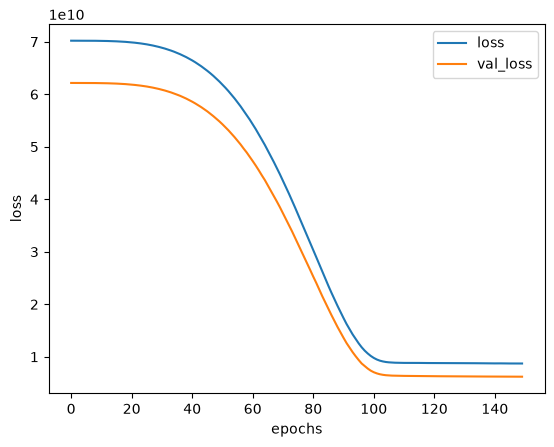

In [45]:
# Visualize Epochs vs. Loss for the Training Loss and Validation Loss
history_df[['loss', 'val_loss']].plot()
plt.xlabel('epochs')
plt.ylabel('loss');

## 12. Early Stopping (callback)

- Prevent overfitting
- will not waste the computing power
- save time
  
It is hard to guess exactly how many epochs a model needs. If you train for too few epochs, the model underfits. If you train for too many, it overfits. 

An **Early Stopping Callback** acts as an automatic brake. It monitors the validation loss and automatically stops training once the validation score stops improving, even if you haven't reached your maximum number of epochs. It can also automatically restore the model's best weights!

In [46]:
# configure EarlyStopping parameters
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [47]:
# Use the validation
# Step 1: Define
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(30, activation='relu'))
model.add(Dense(20, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(1, activation='linear'))

# Step 2: Compile
model.compile(loss='mse', metrics=['mae'])

# Step 3: Fit
history = model.fit(X_train_sc, y_train,validation_data=(X_val_sc, y_val),epochs=300,batch_size=16,callbacks=[es])

Epoch 1/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 70197248000.0000 - mae: 234510.6406 - val_loss: 62150799360.0000 - val_mae: 221360.8438
Epoch 2/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 70196297728.0000 - mae: 234508.7969 - val_loss: 62149574656.0000 - val_mae: 221358.3125
Epoch 3/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 70194561024.0000 - mae: 234505.3438 - val_loss: 62147481600.0000 - val_mae: 221353.8594
Epoch 4/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 70191611904.0000 - mae: 234499.6094 - val_loss: 62144053248.0000 - val_mae: 221346.6250
Epoch 5/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 70187032576.0000 - mae: 234490.7656 - val_loss: 62138855424.0000 - val_mae: 221335.5938
Epoch 6/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70180511744.0000 - mae: 234477.7812 - val_loss: 62131851264.0000 - val_mae: 221320.5625
Epoch 7/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70171549696.0000 - mae: 234459.9375 - val_loss: 6212189798

In [48]:
# Model Weights
model.weights


[<Variable path=sequential_8/dense_23/kernel, shape=(1, 30), dtype=float32, value=[[-0.01151548 -0.02222986 -0.44860777  2.2433953   2.0981739  -0.9805394
   -0.806464    2.309898    2.102036    2.283845    1.904546    2.0288184
   -0.80348366 -1.0560544  -0.9160003   0.00342911  0.7076156   2.3231723
    2.3963454   2.212538   -0.45112655  2.3482013  -0.925282    1.9496746
    1.9633906   1.9690169   2.3495793   0.7050451   2.2243288  -0.912919  ]]>,
 <Variable path=sequential_8/dense_23/bias, shape=(30,), dtype=float32, value=[-0.01976382  2.7478728   2.828193    2.772146    2.5709605   2.8506193
   2.819751    2.7987134   2.7592313   2.7890966   2.747059    2.7499096
   2.830311    2.832686    2.8470366  -0.02302673  2.7463906   2.7970896
   2.7984662   2.7714777   2.8425665   2.7955537   2.8505936   2.7548919
   2.7601452   2.6166208   2.7974954   2.752571    2.7702901   2.852199  ]>,
 <Variable path=sequential_8/dense_24/kernel, shape=(30, 20), dtype=float32, value=[[ 2.48714566e-

In [49]:
# Model Summary
model.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                     │ (None, 30)                  │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 20)                  │             620 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 15)                  │             315 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 1)                   │              16 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,024 (7.91 KB)

 Trainable params: 1,011 (3.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,013 (3.96 KB)

In [50]:
# Create a History Data Frame
history_df = pd.DataFrame(history.history)
history_df

,loss,mae,val_loss,val_mae
0,7.019725e+10,234510.640625,6.215080e+10,221360.843750
1,7.019630e+10,234508.796875,6.214957e+10,221358.312500
2,7.019456e+10,234505.343750,6.214748e+10,221353.859375
3,7.019161e+10,234499.609375,6.214405e+10,221346.625000
4,7.018703e+10,234490.765625,6.213886e+10,221335.593750
...,...,...,...,...
160,8.589480e+09,63258.554688,6.099800e+09,57180.011719
161,8.578231e+09,63182.062500,6.106359e+09,57370.226562
162,8.586705e+09,63379.714844,6.106678e+09,57397.957031
163,8.584506e+09,63369.375000,6.106077e+09,57407.304688


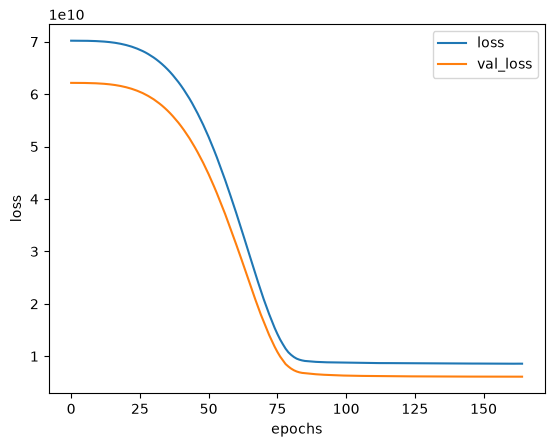

In [51]:
# Visualize Epochs vs. Loss for the Training Loss and Validation Loss
history_df[['loss', 'val_loss']].plot()
plt.xlabel('epochs')
plt.ylabel('loss');

## 13.Multi-Feature Neural Network

In [52]:
X = housing[['beds', 'baths', 'sq__ft']]
y = housing['price']

X_train_all, X_test, y_train_all, y_test = train_test_split(X, y, test_size=0.20,random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_all, y_train_all,test_size=0.20, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

In [53]:
# configure EarlyStopping parameters
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


In [54]:
# Use the validation
# Step 1: Define
model = Sequential([
    Input(shape=(3,)),             
    Dense(30, activation='relu'),
    Dense(20, activation='relu'),
    Dense(15, activation='relu'),
    Dense(1, activation='linear')
])

# Step 2: Compile
model.compile(loss='mse', metrics=['mae'])

# Step 3: Fit
history = model.fit(X_train_sc, y_train,validation_data=(X_val_sc, y_val),epochs=300,batch_size=16,callbacks=[es])

model.evaluate(X_test_sc, y_test)

Epoch 1/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 70197493760.0000 - mae: 234511.0469 - val_loss: 62151172096.0000 - val_mae: 221361.5000
Epoch 2/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 70196961280.0000 - mae: 234510.0000 - val_loss: 62150524928.0000 - val_mae: 221360.1094
Epoch 3/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 70196060160.0000 - mae: 234508.1875 - val_loss: 62149373952.0000 - val_mae: 221357.5469
Epoch 4/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 70194520064.0000 - mae: 234505.0156 - val_loss: 62147473408.0000 - val_mae: 221353.3125
Epoch 5/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 70191841280.0000 - mae: 234499.6875 - val_loss: 62144151552.0000 - val_mae: 221346.0156
Epoch 6/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 70187679744.0000 - mae: 234491.2812 - val_loss: 62139240448.0000 - val_mae: 221335.1562
Epoch 7/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 70181257216.0000 - mae: 234478.5312 - val_loss: 62131

[5856910848.0, 56064.21484375]

In [55]:
# Model Weights
model.weights


[<Variable path=sequential_9/dense_27/kernel, shape=(3, 30), dtype=float32, value=[[-0.583072   -0.78326046  0.47288936  0.37222588 -0.28332904 -0.4025318
   -0.73970956 -1.0212513  -1.1340435  -0.10763712  0.25102288 -0.8758886
    0.13208526  0.42633575  0.58757013 -0.97932583 -0.25880912 -0.00361822
    0.5516804  -0.95883286 -0.6962741  -1.0970727   0.5615087   0.2826971
    0.308341    0.50063175  0.13226157 -1.05716    -0.8563181  -0.0541228 ]
  [-0.9537576  -0.9024594   0.28561088  0.74230635  1.2985039   1.4032941
   -0.8149572  -1.0438274  -0.61730254  0.75931275  0.5159767  -0.64085007
    1.2410517   0.18412116  0.2728481  -0.6955854  -1.1424218   1.1290001
    0.854393   -0.7929434  -0.7292763  -0.4356209   1.0519657   0.5556663
    1.1348387   0.23437023  1.2387344  -1.0367012  -0.892106    1.1643801 ]
  [ 0.5028845   0.37245154  2.3794367   2.1349664   2.2522402   2.258345
    0.38933262  0.631633    0.41812077  2.43174     2.5084825   0.43044913
    1.7965156   2.3693805

In [56]:
# Model Summary
model.summary()


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                     │ (None, 30)                  │             120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 20)                  │             620 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 15)                  │             315 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 1)                   │              16 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,144 (8.38 KB)

 Trainable params: 1,071 (4.18 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,073 (4.20 KB)

In [57]:
# Create a History Data Frame
history_df = pd.DataFrame(history.history)
history_df

,loss,mae,val_loss,val_mae
0,7.019749e+10,234511.046875,6.215117e+10,221361.500000
1,7.019696e+10,234510.000000,6.215052e+10,221360.109375
2,7.019606e+10,234508.187500,6.214937e+10,221357.546875
3,7.019452e+10,234505.015625,6.214747e+10,221353.312500
4,7.019184e+10,234499.687500,6.214415e+10,221346.015625
...,...,...,...,...
295,8.383649e+09,63007.652344,6.020792e+09,57538.828125
296,8.373283e+09,62905.917969,6.019718e+09,57521.292969
297,8.380317e+09,62936.515625,6.019983e+09,57539.871094
298,8.372363e+09,62870.066406,6.020470e+09,57564.128906


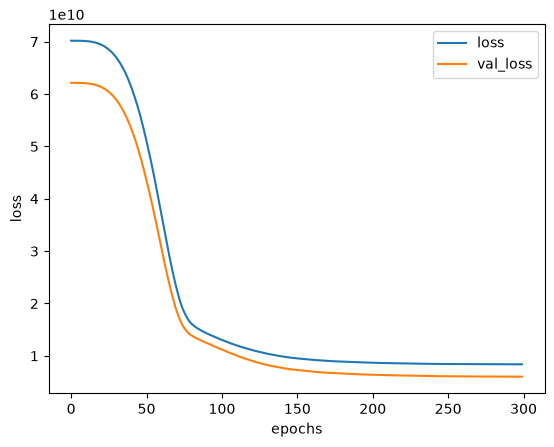

In [58]:
# Visualize Epochs vs. Loss for the Training Loss and Validation Loss
history_df[['loss', 'val_loss']].plot()
plt.xlabel('epochs')
plt.ylabel('loss');